<a href="https://colab.research.google.com/github/Prithviraj108/heart-disease-prediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Heart Disease Prediction
**Dataset:** prithvirajshukla/heart-disease-prediction  
**Goal:** Binary classification — predict `heart_disease_present` (0 = no disease, 1 = disease)  
**Key metric:** Recall (minimise false negatives — missing a sick patient is costlier than a false alarm)

---
### Column name reference (short names used throughout)
| Short name | Original column |
|---|---|
| `sop` | slope_of_peak_exercise_st_segment |
| `resting_bp` | resting_blood_pressure |
| `cpt` | chest_pain_type |
| `major_vessels` | num_major_vessels |
| `fasting_blood_sugar` | fasting_blood_sugar_gt_120_mg_per_dl |
| `ekg_result` | resting_ekg_results |
| `serum_cholesterol` | serum_cholesterol_mg_per_dl |
| `oldpeak_st_depression` | oldpeak_eq_st_depression |
| `max_heart_rate` | max_heart_rate_achieved |
| `heart_disease` | heart_disease_present (target) |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
import pickle
%matplotlib inline

## 2. Load & Merge Data
> **Fix applied:** replaced `pd.concat(..., axis=1)` with `.merge(on='patient_id')` — concat joins by row position which silently mismatches labels if files are sorted differently.

In [2]:
%%writefile kaggle.json
{
  "username": "prithvirajshukla",
  "key": "KGAT_26259447ac12dbf77822d7174f1a3782"
}

Writing kaggle.json


In [3]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_26259447ac12dbf77822d7174f1a3782'

kaggle_config_dir = '/root/.config/kaggle'
kaggle_json_path = os.path.join(kaggle_config_dir, 'kaggle.json')

# Only ask for kaggle.json if not already configured
if not os.path.exists(kaggle_json_path):
    # Check if kaggle.json was created in the current directory
    if os.path.exists('kaggle.json'):
        print("Moving kaggle.json from current directory to Kaggle config directory.")
        os.makedirs(kaggle_config_dir, exist_ok=True)
        os.rename('kaggle.json', kaggle_json_path)
        os.chmod(kaggle_json_path, 0o600)
        print("Kaggle credentials saved!")
    else:
        from google.colab import files
        print("Please upload your kaggle.json API key file:")
        files.upload()
        os.makedirs(kaggle_config_dir, exist_ok=True)
        os.rename('kaggle.json', kaggle_json_path)
        os.chmod(kaggle_json_path, 0o600)
        print("Kaggle credentials saved!")
else:
    print("Kaggle credentials already configured.")

# Download dataset
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download('prithvirajshukla/heart-disease-prediction')
print("Dataset path:", path)

# Load files
import pandas as pd
df  = pd.read_csv(f'{path}/values.csv')
df1 = pd.read_csv(f'{path}/labels.csv')

data = df.merge(df1, on='patient_id')
print(f'Shape: {data.shape}')
data.head()

Moving kaggle.json from current directory to Kaggle config directory.
Kaggle credentials saved!


100%|██████████| 541k/541k [00:00<00:00, 1.25MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/prithvirajshukla/heart-disease-prediction/versions/1
Shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [4]:
data.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [5]:
data.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [6]:
data.shape

(180, 15)

## 3. Examine the Data

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

### Statistical summary

In [8]:
data.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


## 4. Exploratory Data Analysis (EDA)
### 4.1 Rename columns for readability
Original column names are renamed to shorter aliases. See the reference table in the header.

In [9]:
data.rename({
    'slope_of_peak_exercise_st_segment': 'sop',
    'resting_blood_pressure':            'resting_bp',
    'chest_pain_type':                   'cpt',
    'num_major_vessels':                 'major_vessels',
    'fasting_blood_sugar_gt_120_mg_per_dl': 'fasting_blood_sugar',
    'resting_ekg_results':               'ekg_result',
    'serum_cholesterol_mg_per_dl':       'serum_cholesterol',
    'oldpeak_eq_st_depression':          'oldpeak_st_depression',
    'max_heart_rate_achieved':           'max_heart_rate',
    'heart_disease_present':             'heart_disease'
}, inplace=True, axis=1)
data.head()

,patient_id,sop,thal,resting_bp,cpt,major_vessels,fasting_blood_sugar,ekg_result,serum_cholesterol,oldpeak_st_depression,sex,age,max_heart_rate,exercise_induced_angina,heart_disease
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


### 4.2 Univariate Analysis — sweetviz report

In [10]:
!pip install sweetviz -q
import sweetviz
univariate = data[['sop','thal','resting_bp','cpt','major_vessels','fasting_blood_sugar',
                   'ekg_result','serum_cholesterol','oldpeak_st_depression','sex','age',
                   'max_heart_rate','exercise_induced_angina','heart_disease']]
sv = sweetviz.analyze(univariate)
sv.show_html()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 62.4 MB/s eta 0:00:00


                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Observations:**
1. **SOP:** 3 categories — 52% upsloping, 42% flat, 7% downsloping
2. **Thal:** normal (98), reversible_defect (74), fixed_defect (8)
3. **Resting BP:** range 94–180, average 131.3; most patients at 130
4. **Chest pain:** 46% asymptomatic, 32% non-anginal, 16% atypical angina, 7% typical angina
5. **Major vessels:** mostly 0 (106 patients)
6. **Fasting blood sugar:** 151 < 120 mg/dl, 29 ≥ 120 mg/dl
7. **EKG result:** 52% value 2, 47% normal (0)
8. **Serum cholesterol:** range 126–564; most frequent 239 & 204
9. **Oldpeak ST depression:** range 0–6.20
10. **Sex:** 124 male, 56 female
11. **Age:** range 29–77, average 54.8 years
12. **Max heart rate:** range 96–202; most between 140–180
13. **Exercise induced angina:** 123 no, 57 yes
14. **Target (heart_disease):** 100 no disease, 80 disease

### 4.3 Bivariate Analysis — categorical features vs target

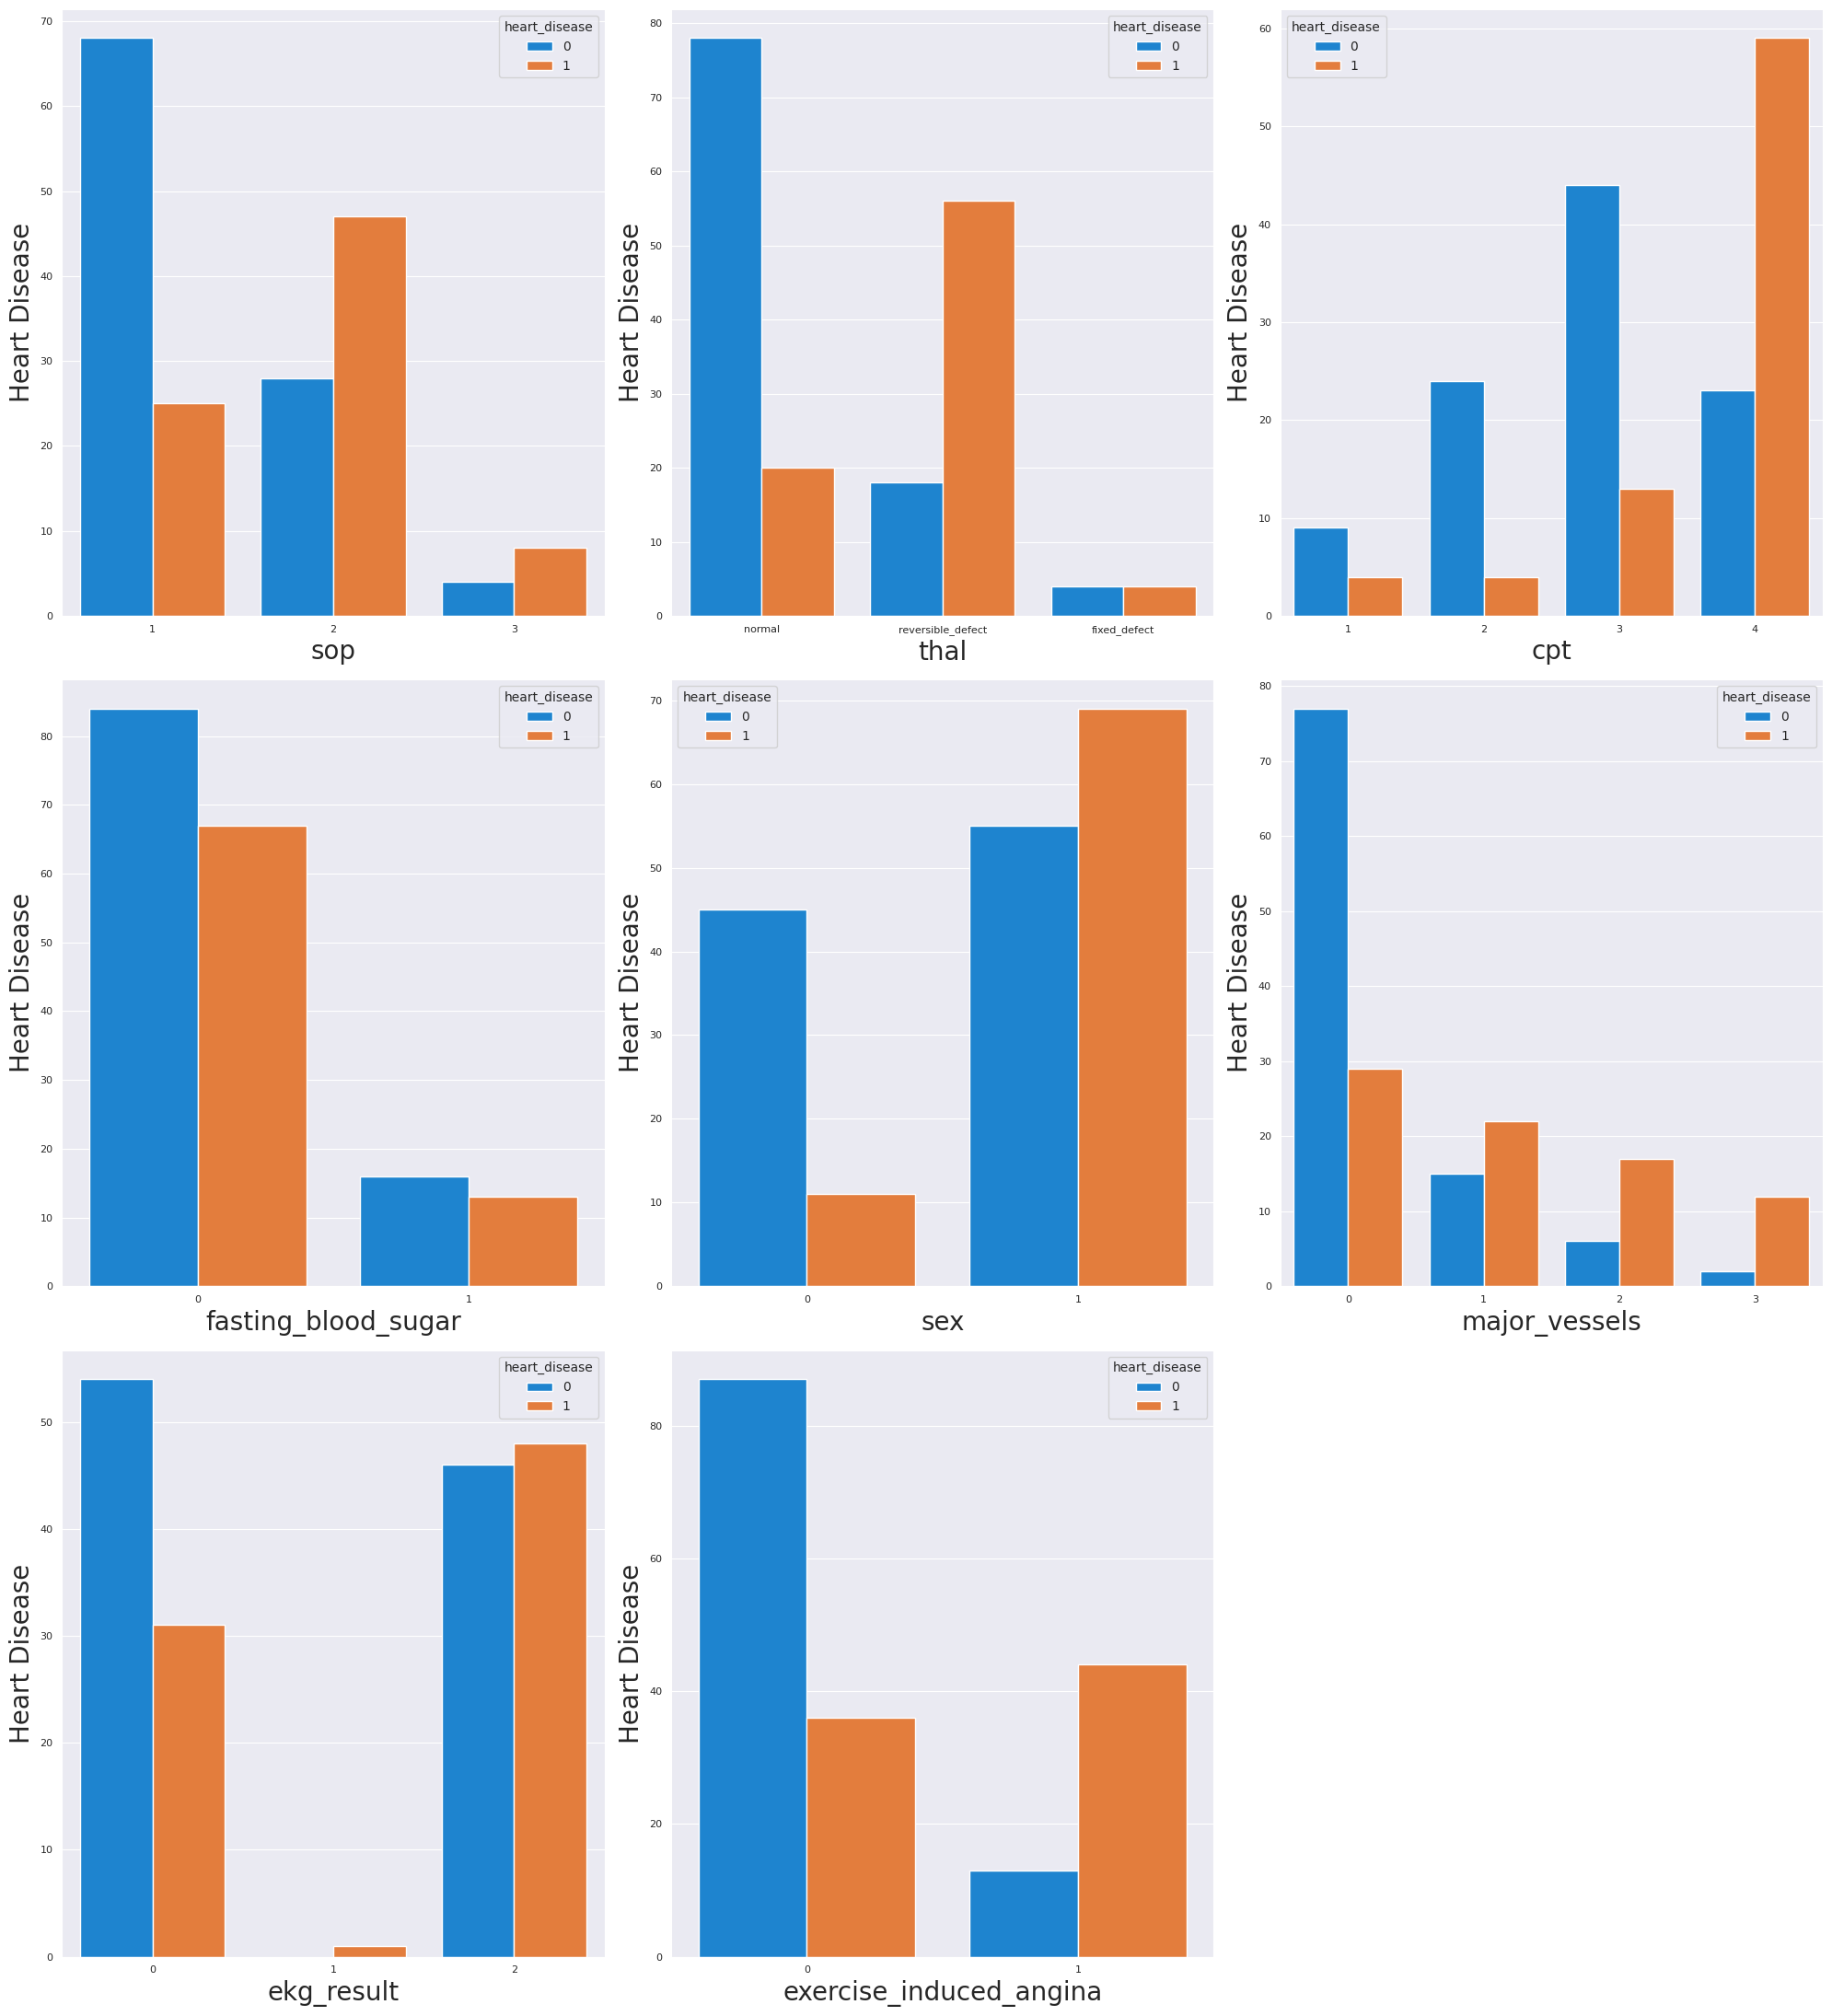

In [11]:
categorical = data[['sop','thal','cpt','fasting_blood_sugar','sex',
                     'major_vessels','ekg_result','exercise_induced_angina']]
sns.set_style('darkgrid')
plt.figure(figsize=(20, 22), facecolor='white')
plotnumber = 1

for column in categorical:
    if plotnumber <= 9:
        ax = plt.subplot(3, 3, plotnumber)
        sns.countplot(x=categorical[column], hue=data.heart_disease)
        plt.xlabel(column, fontsize=20)
        plt.ylabel('Heart Disease', fontsize=20)
    plotnumber += 1

plt.tight_layout()
plt.show()

### 4.4 Bivariate Analysis — numerical features vs target

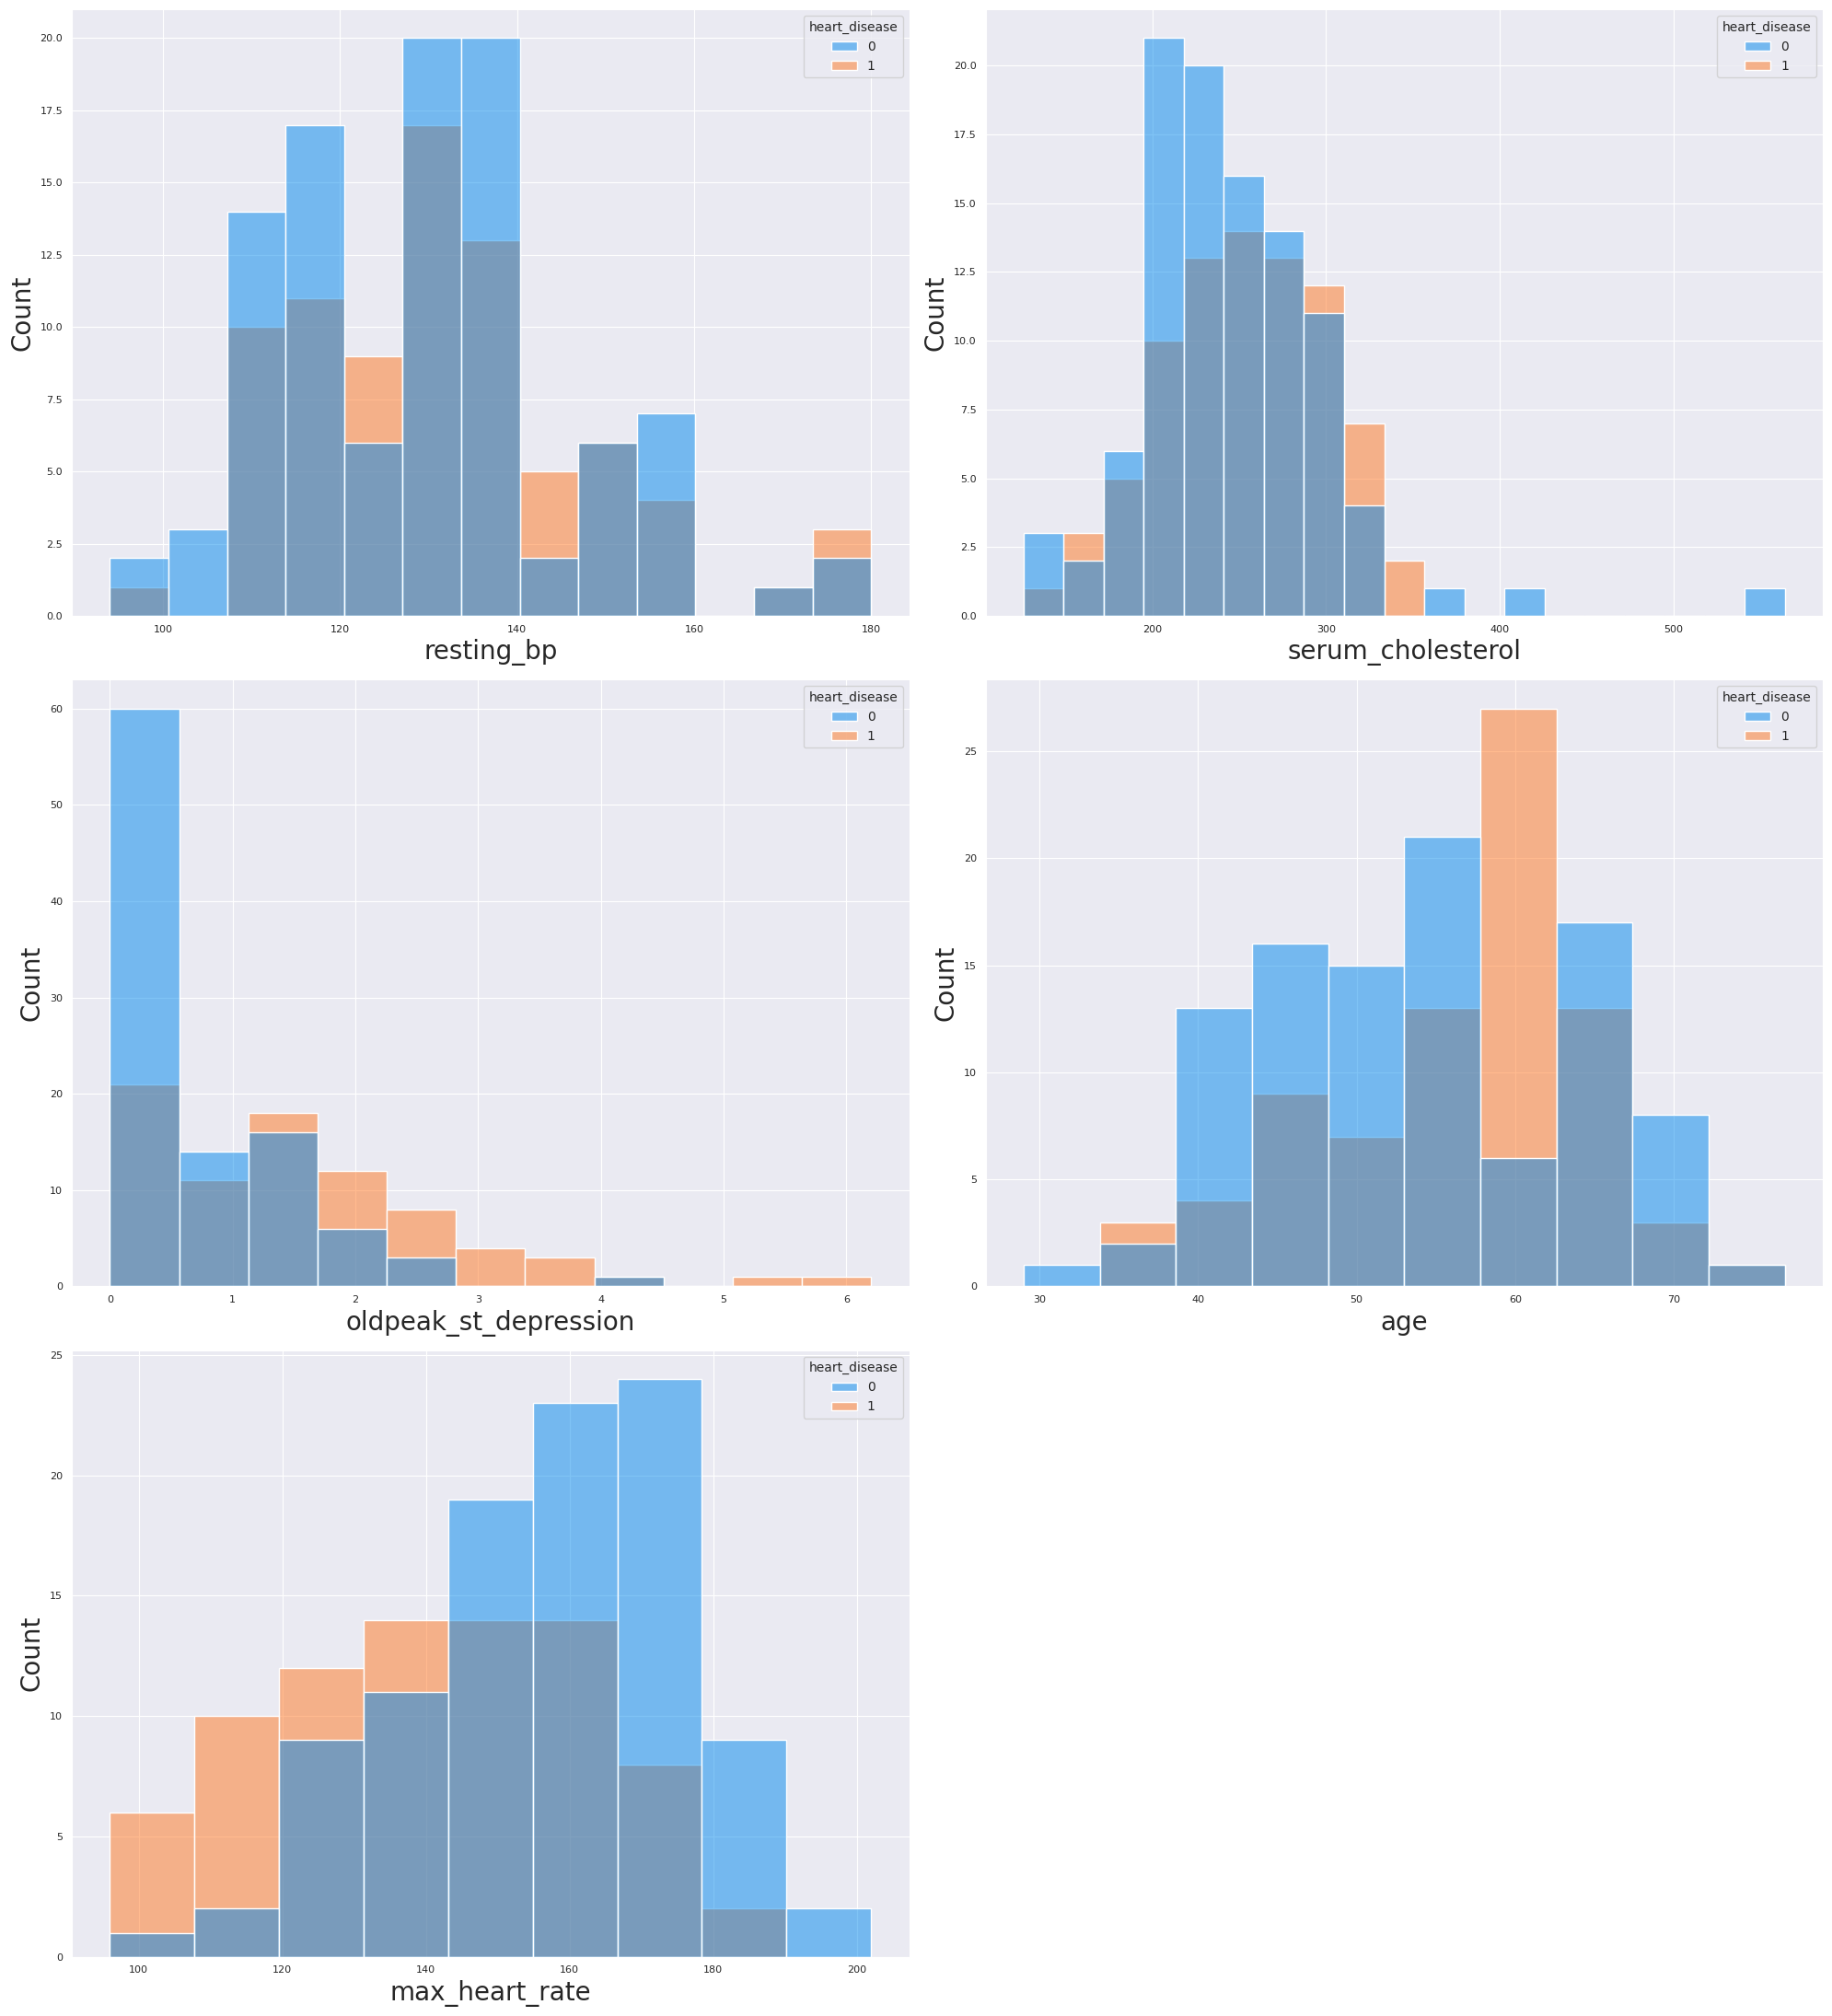

In [12]:
numerical = data[['resting_bp','serum_cholesterol','oldpeak_st_depression','age','max_heart_rate']]
sns.set_style('darkgrid')
plt.figure(figsize=(20, 22))
plotno = 1

for column in numerical:
    if plotno <= 9:
        plt.subplot(3, 2, plotno)
        sns.histplot(x=numerical[column], hue=data.heart_disease)
        plt.ylabel('Count', fontsize=20)
        plt.xlabel(column, fontsize=20)
    plotno += 1

plt.tight_layout()
plt.show()

### 4.5 Multivariate Analysis — pairwise relationships vs target

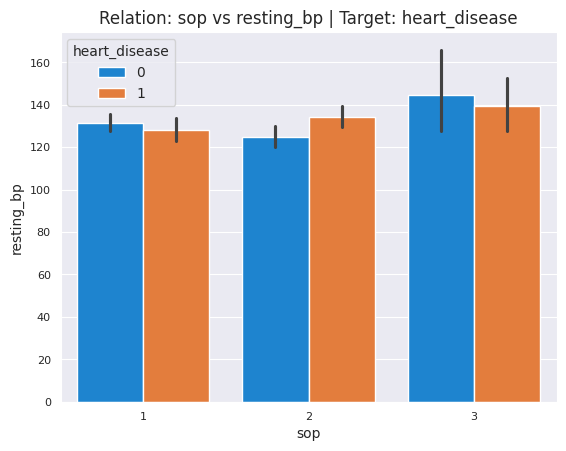

In [13]:
sns.barplot(x='sop', y='resting_bp', hue=data.heart_disease, data=data)
plt.title('Relation: sop vs resting_bp | Target: heart_disease')
plt.show()

**Observation:** Rising resting BP with flat/downsloping ST segment increases heart disease risk equally.

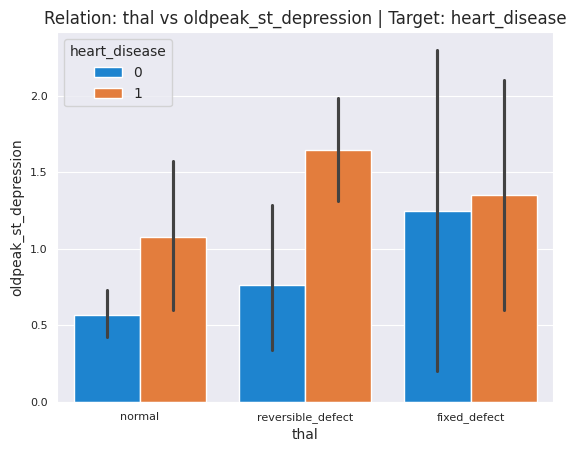

In [14]:
sns.barplot(x='thal', y='oldpeak_st_depression', hue=data.heart_disease, data=data)
plt.title('Relation: thal vs oldpeak_st_depression | Target: heart_disease')
plt.show()

**Observation:** Reversible defect + high oldpeak → highest disease chance. Fixed defect above 1 → equal chance.

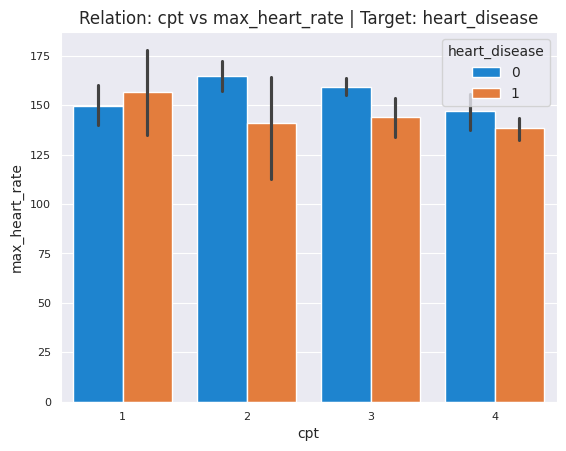

In [15]:
sns.barplot(x='cpt', y='max_heart_rate', hue=data.heart_disease, data=data)
plt.title('Relation: cpt vs max_heart_rate | Target: heart_disease')
plt.show()

**Observation:** All chest pain types with max heart rate below 150 show equal disease probability.

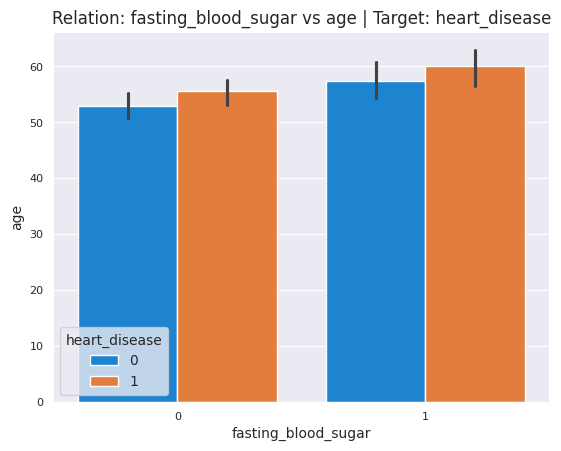

In [16]:
sns.barplot(x='fasting_blood_sugar', y='age', hue=data.heart_disease, data=data)
plt.title('Relation: fasting_blood_sugar vs age | Target: heart_disease')
plt.show()

**Observation:** Both blood sugar categories show 50-50 disease chance up to age 60.

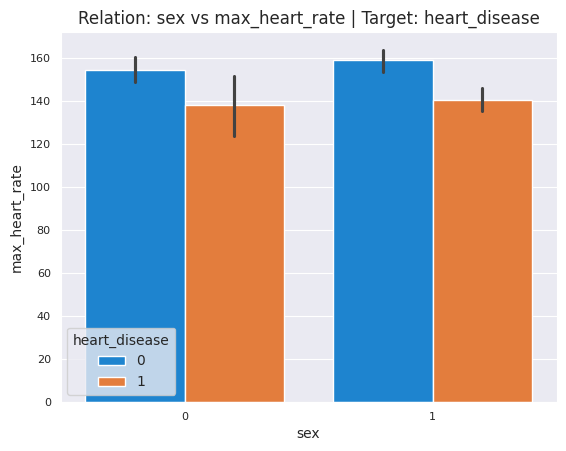

In [17]:
sns.barplot(x='sex', y='max_heart_rate', hue=data.heart_disease, data=data)
plt.title('Relation: sex vs max_heart_rate | Target: heart_disease')
plt.show()

**Observation:** Lower max heart rate increases disease risk for both sexes.

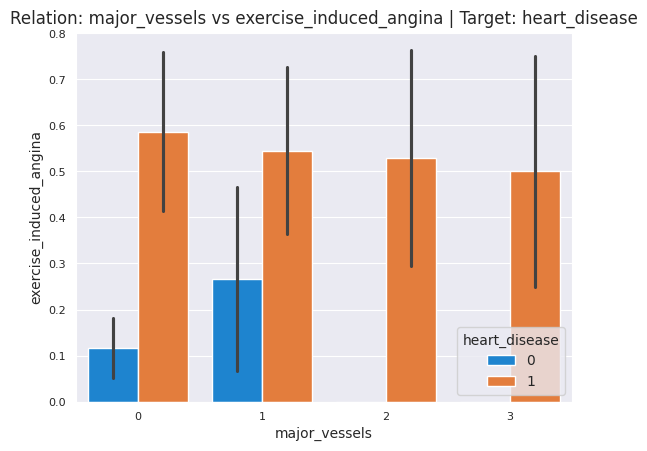

In [18]:
sns.barplot(x='major_vessels', y='exercise_induced_angina', hue=data.heart_disease, data=data)
plt.title('Relation: major_vessels vs exercise_induced_angina | Target: heart_disease')
plt.show()

**Observation:** Higher exercise-induced angina with any vessel count → greater disease chance.

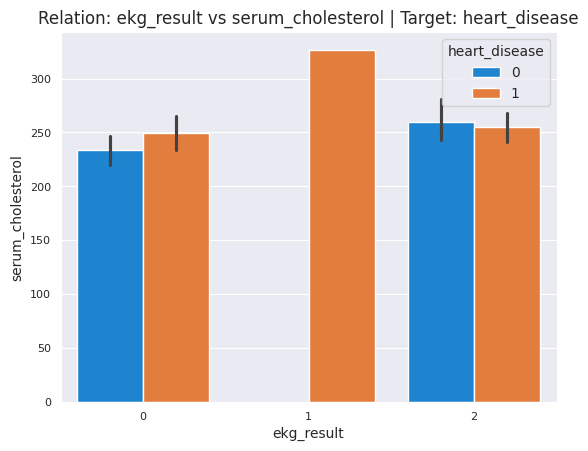

In [19]:
sns.barplot(x='ekg_result', y='serum_cholesterol', hue=data.heart_disease, data=data)
plt.title('Relation: ekg_result vs serum_cholesterol | Target: heart_disease')
plt.show()

**Observation:** EKG result 1 → 100% disease. Results 0 and 2 → equal chance regardless of cholesterol.

## 5. Data Preprocessing & Feature Engineering

### 5.1 Check missing values

In [20]:
data.isnull().sum()

,0
patient_id,0
sop,0
thal,0
resting_bp,0
cpt,0
major_vessels,0
fasting_blood_sugar,0
ekg_result,0
serum_cholesterol,0
oldpeak_st_depression,0


No missing values in this dataset.

### 5.2 Categorical encoding — manual encoding for `thal`
Weights assigned by clinical severity: normal=2, reversible_defect=1, fixed_defect=0

In [21]:
data.thal.value_counts()

,count
thal,
normal,98
reversible_defect,74
fixed_defect,8


In [22]:
data.thal = data.thal.map({'normal': 2, 'reversible_defect': 1, 'fixed_defect': 0})
# normal=2: highest weightage (healthiest)
# reversible_defect=1: intermediate
# fixed_defect=0: lowest (most severe)
print('Unique thal values after encoding:', data.thal.unique())

Unique thal values after encoding: [2 1 0]


### 5.3 Outlier handling — boxplots before treatment

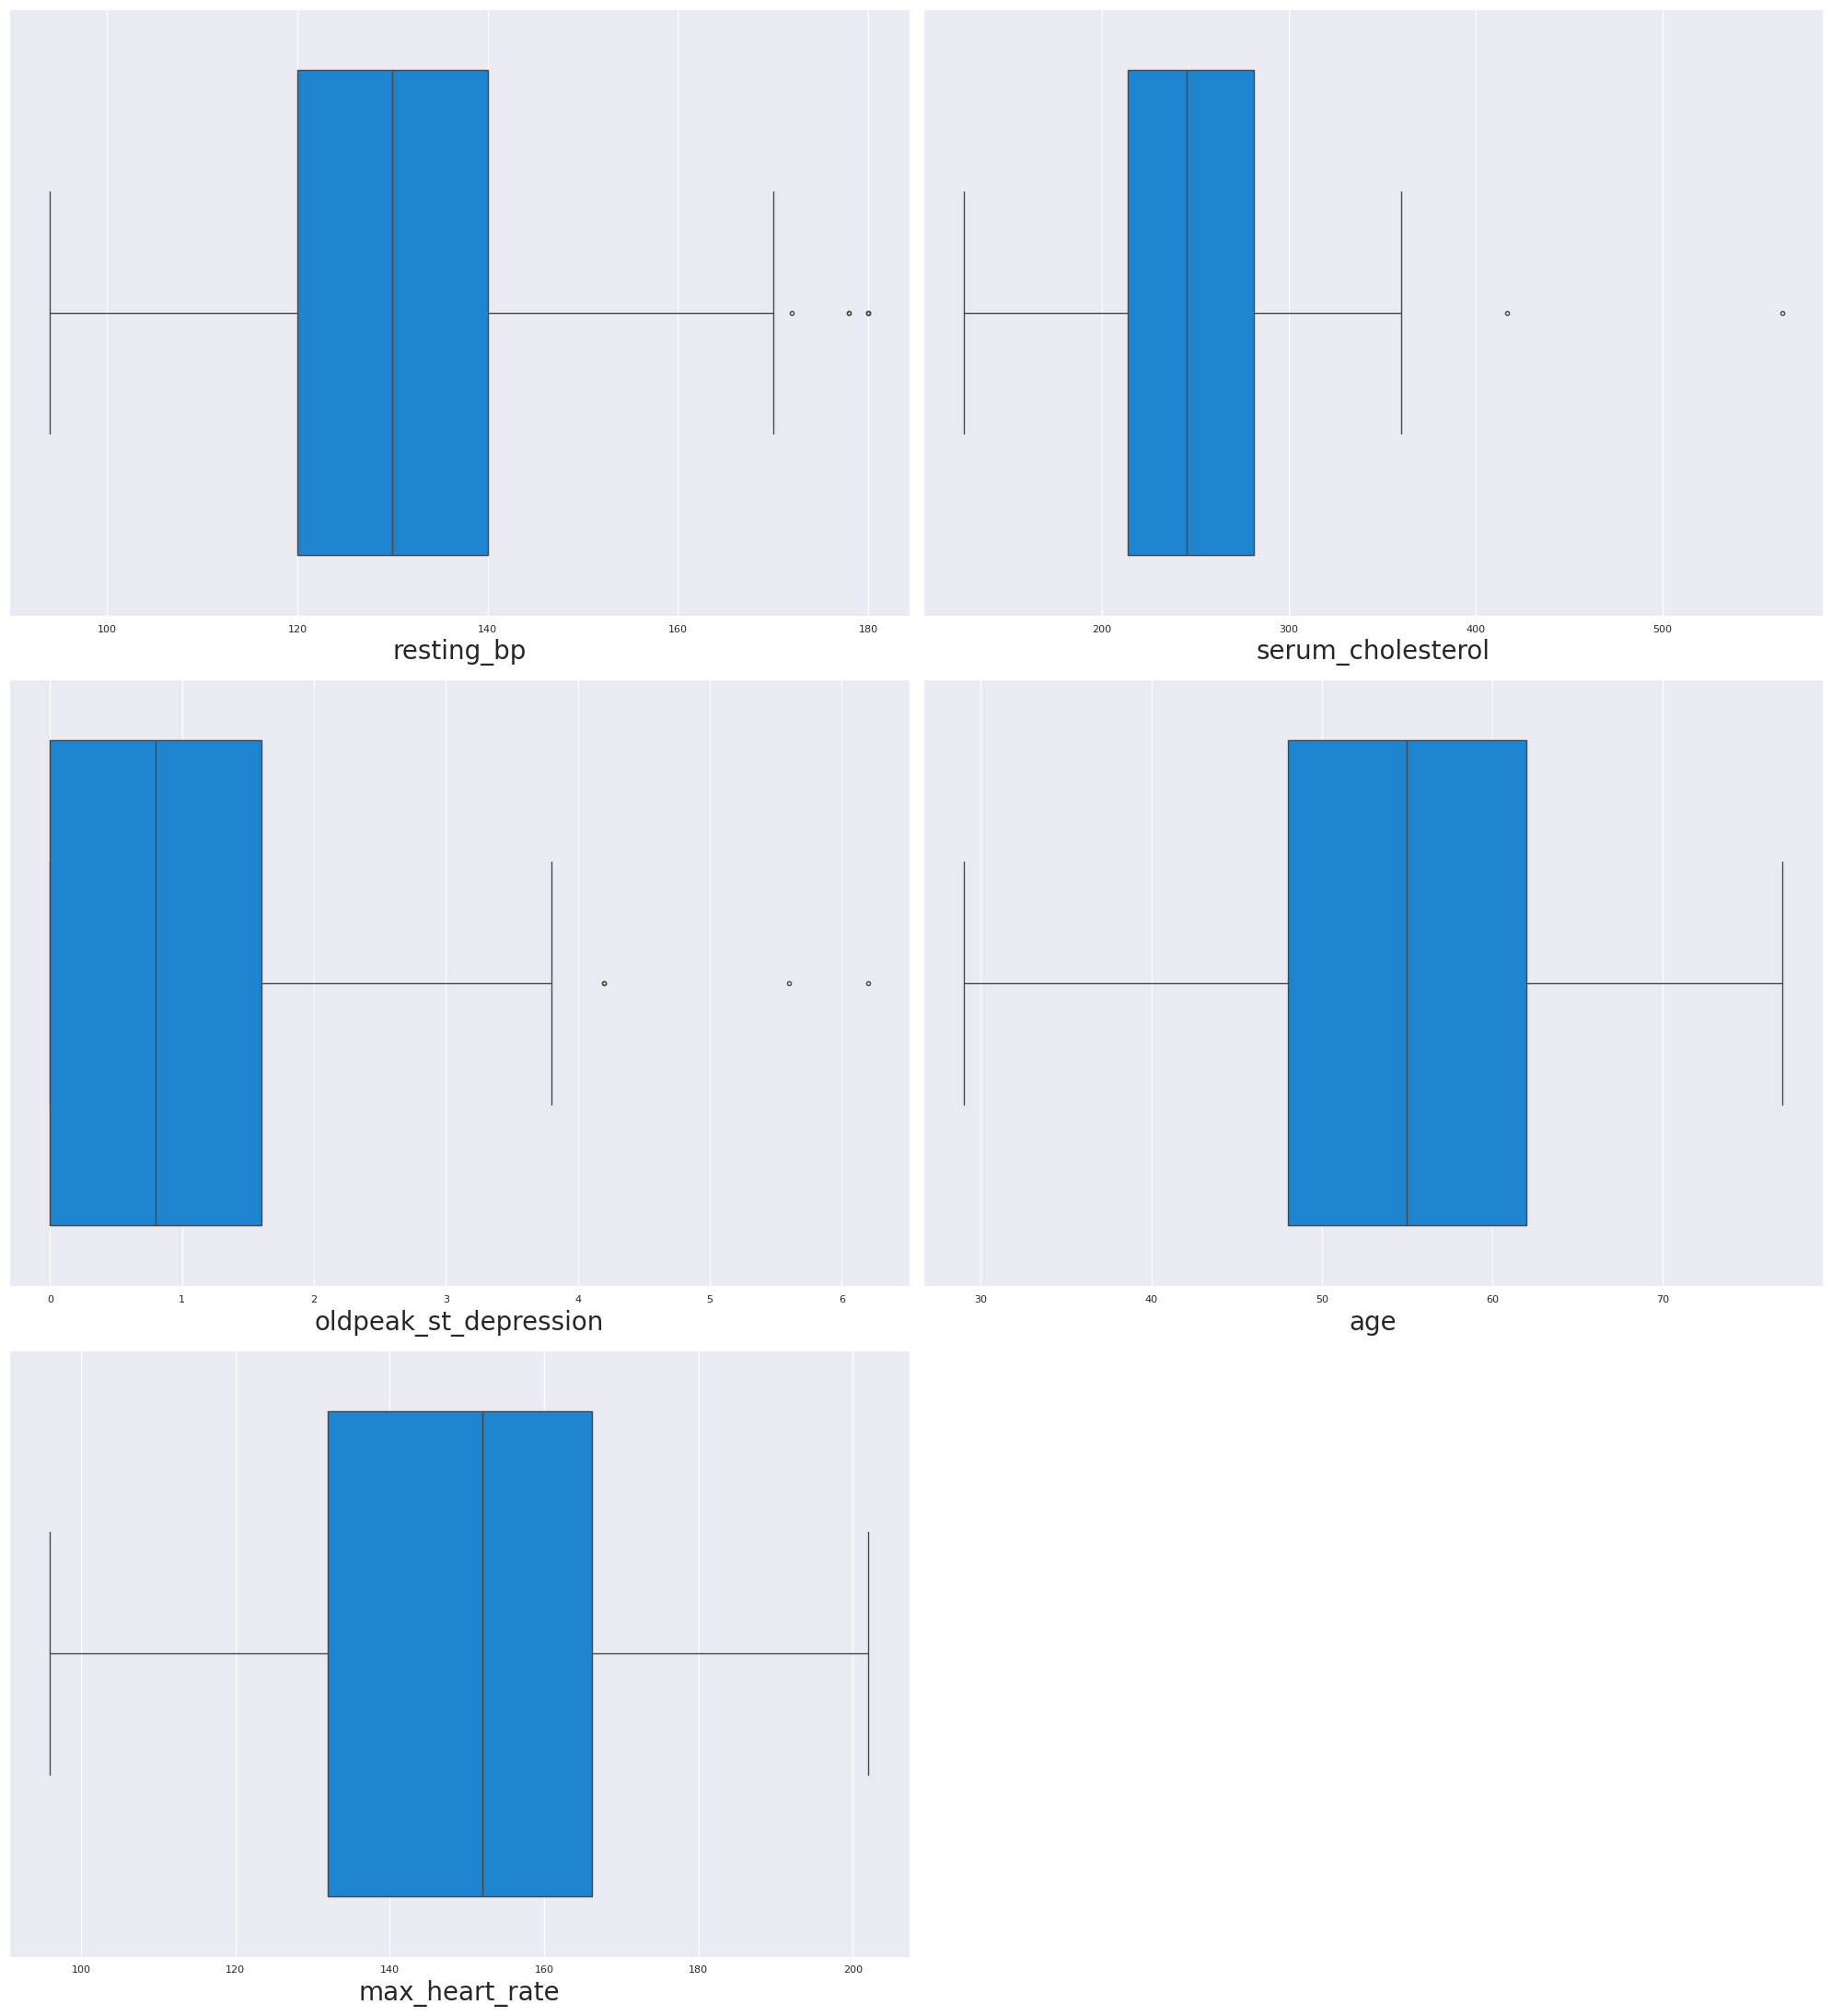

In [23]:
out = data[['resting_bp','serum_cholesterol','oldpeak_st_depression','age','max_heart_rate']]
sns.set_style('darkgrid')
plt.figure(figsize=(20, 22))
plotno = 1

for column in out:
    if plotno <= 6:
        plt.subplot(3, 2, plotno)
        sns.boxplot(x=out[column])
        plt.xlabel(column, fontsize=20)
    plotno += 1

plt.tight_layout()
plt.show()

### Distribution before outlier treatment
> **Fix applied:** replaced deprecated `sns.distplot()` with `sns.histplot(kde=True)` throughout.

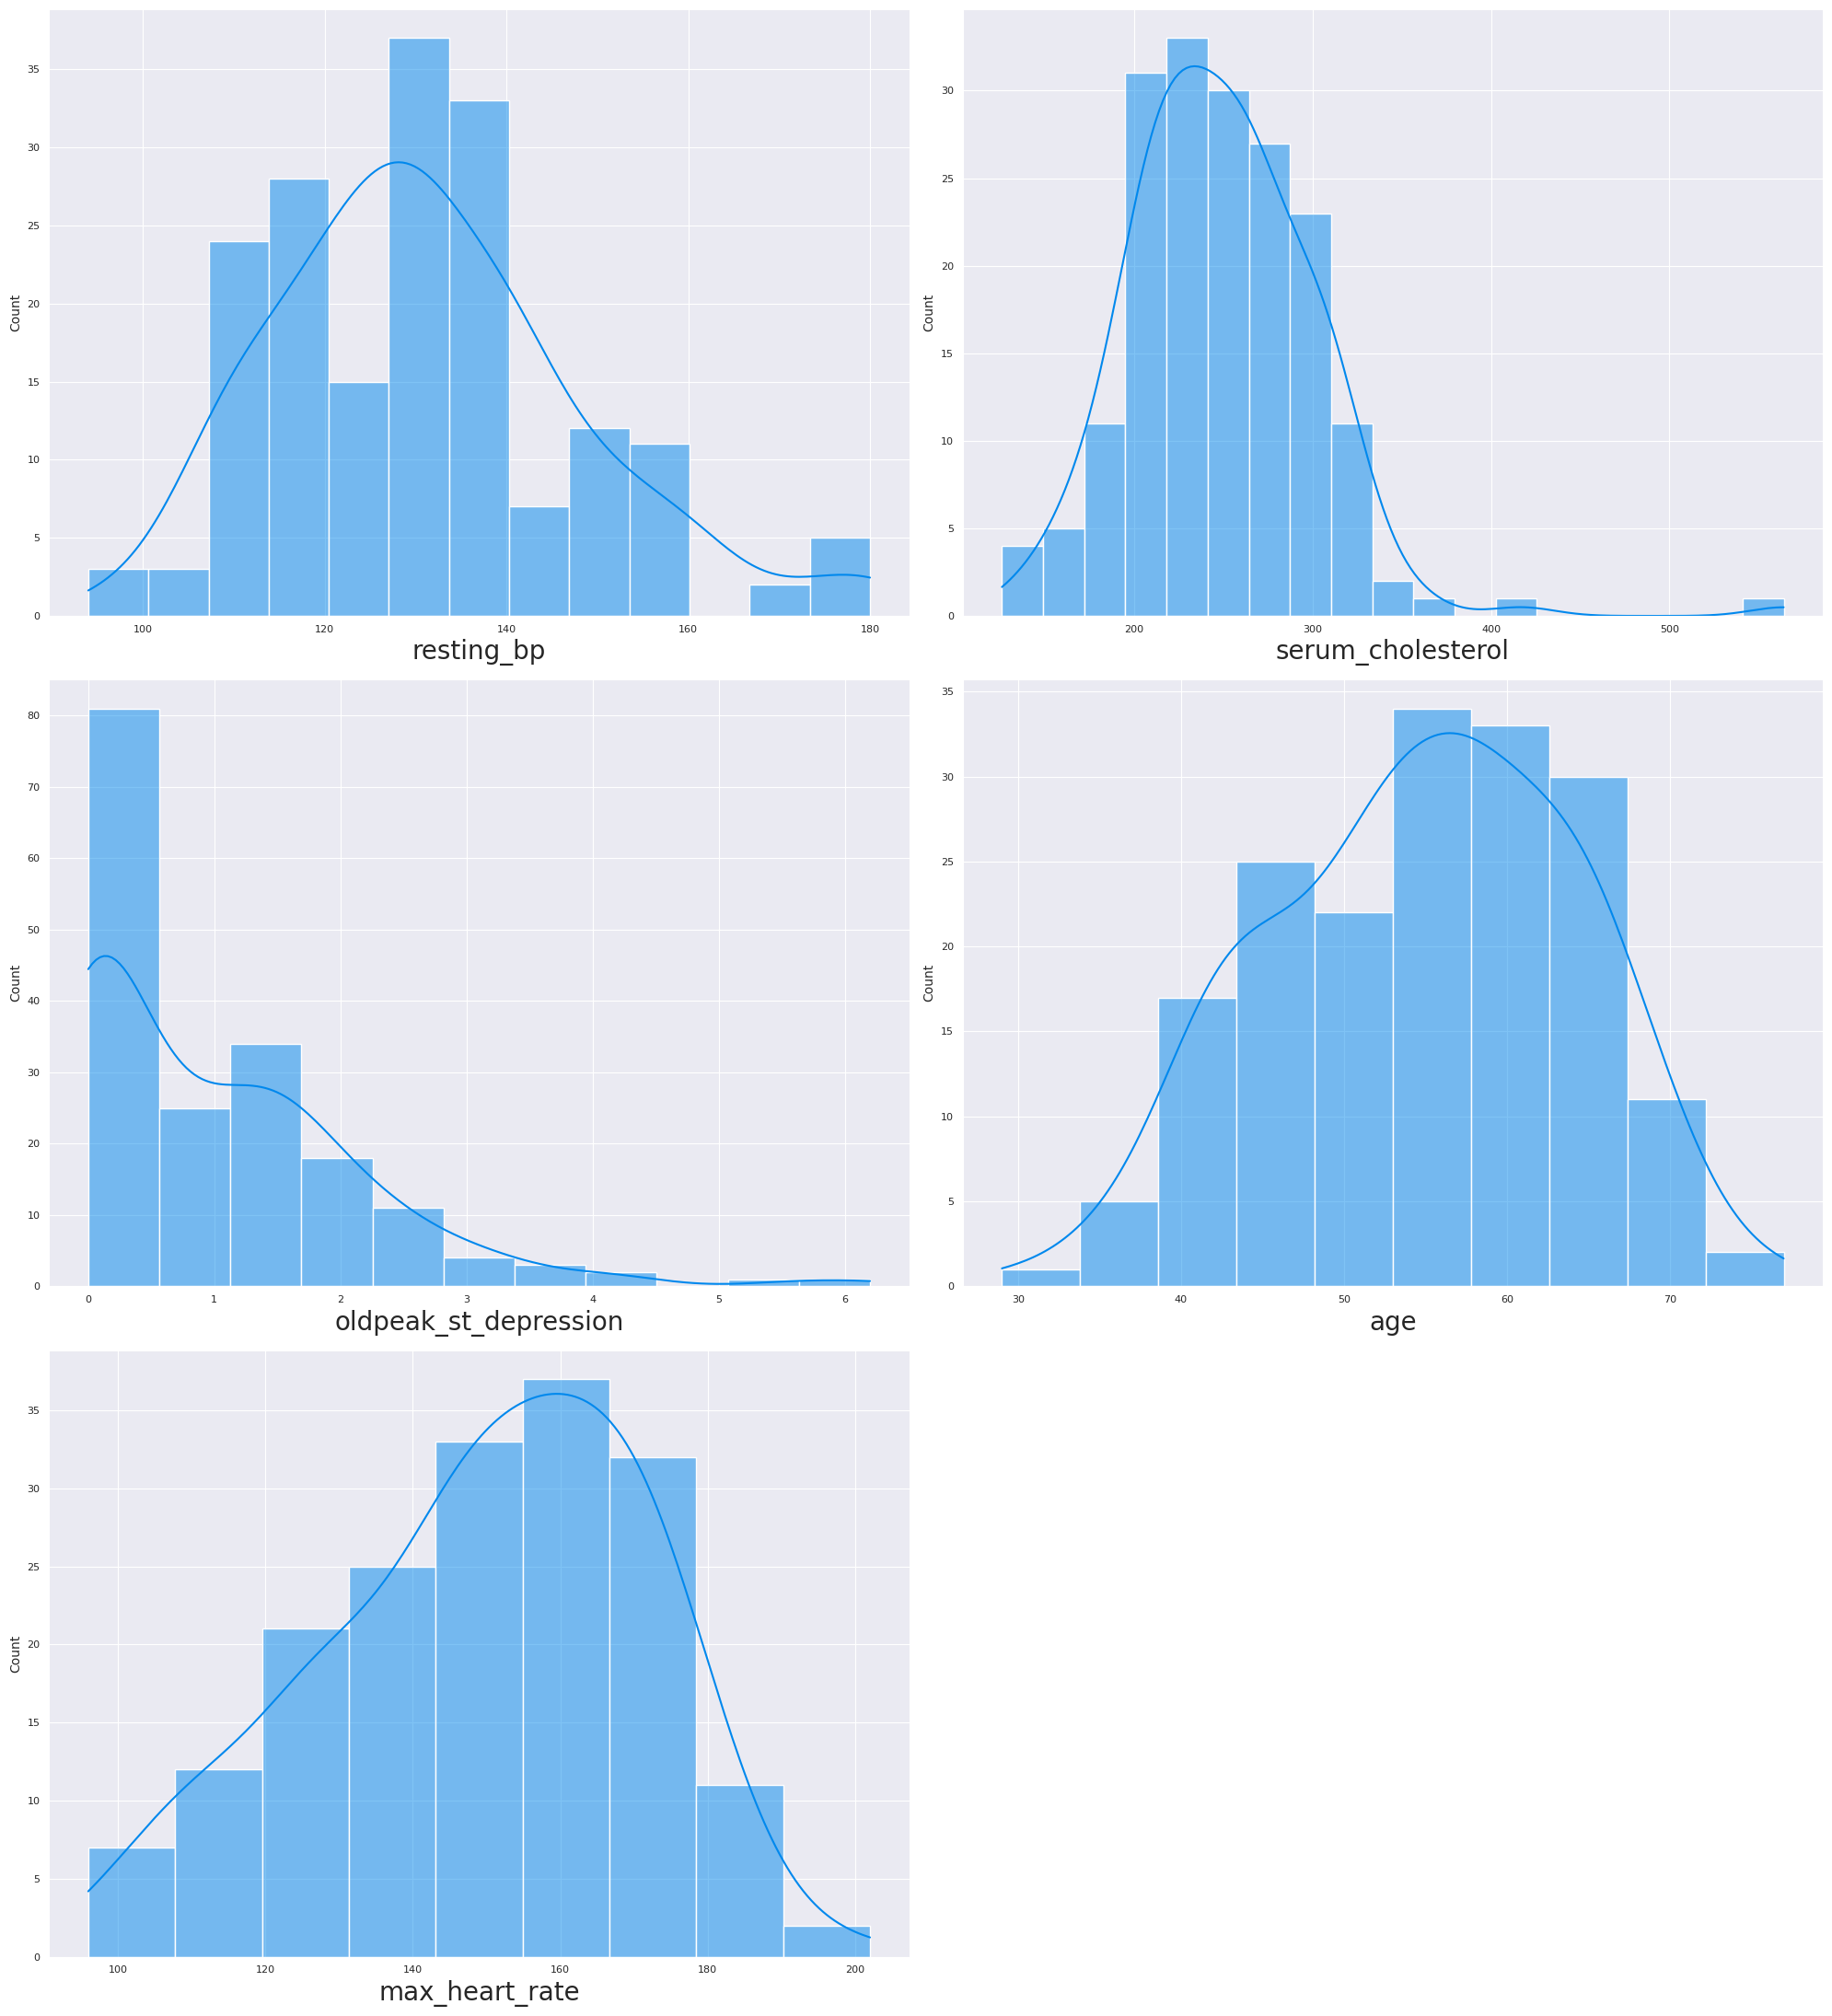

In [24]:
sns.set_style('darkgrid')
plt.figure(figsize=(20, 22))
plotno = 1

for column in out:
    if plotno <= 6:
        plt.subplot(3, 2, plotno)
        sns.histplot(x=out[column], kde=True)  # Fix: was sns.distplot() — deprecated
        plt.xlabel(column, fontsize=20)
    plotno += 1

plt.tight_layout()
plt.show()

#### Resting BP — IQR outlier treatment

IQR: 20.0
Min limit: 90.0 | Max limit: 170.0
Outliers below min: 0
Outliers above max: 6


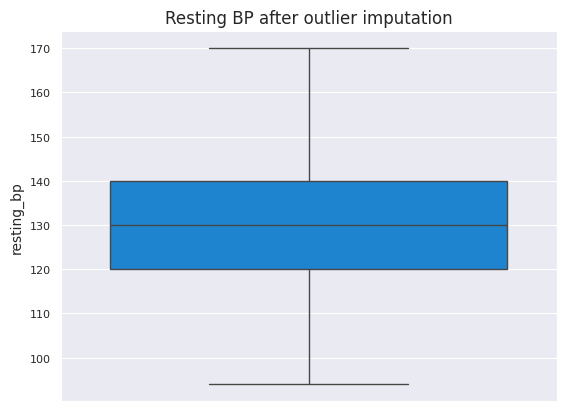

In [25]:
# Step 1: IQR
iqr = stats.iqr(data['resting_bp'], interpolation='midpoint')
print('IQR:', iqr)

# Step 2: Limits
Q1 = data['resting_bp'].quantile(0.25)
Q3 = data['resting_bp'].quantile(0.75)
min_limit = Q1 - 1.5 * iqr
max_limit = Q3 + 1.5 * iqr
print('Min limit:', min_limit, '| Max limit:', max_limit)

# Step 3: Filter
print('Outliers below min:', len(data.loc[data['resting_bp'] < min_limit]))
print('Outliers above max:', len(data.loc[data['resting_bp'] > max_limit]))

# Step 4: Impute with median
data.loc[data['resting_bp'] > max_limit, 'resting_bp'] = np.median(data['resting_bp'])

# Step 5: Verify
sns.boxplot(data.resting_bp)
plt.title('Resting BP after outlier imputation')
plt.show()

#### Serum Cholesterol — IQR outlier treatment
> **Fix applied:** outliers were identified but never imputed in the original notebook. Imputation added.

IQR: 68.0
Min limit: 111.75 | Max limit: 383.25
Outliers below min: 0
Outliers above max: 2
Outlier % above max: 1.11


/tmp/ipykernel_3131/3529573033.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '245.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['serum_cholesterol'] > max_limit, 'serum_cholesterol'] = np.median(data['serum_cholesterol'])


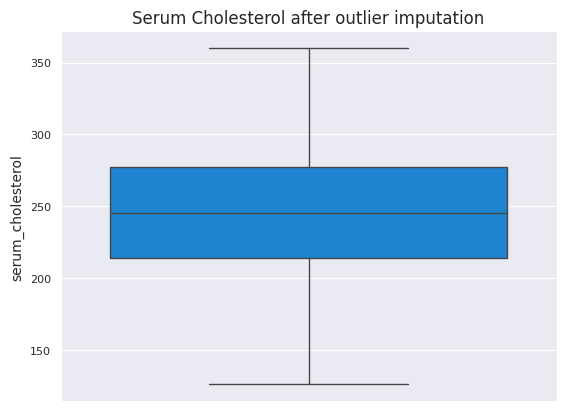

In [26]:
# Step 1: IQR
iqr = stats.iqr(data['serum_cholesterol'], interpolation='midpoint')
print('IQR:', iqr)

# Step 2: Limits
Q1 = data['serum_cholesterol'].quantile(0.25)
Q3 = data['serum_cholesterol'].quantile(0.75)
min_limit = Q1 - 1.5 * iqr
max_limit = Q3 + 1.5 * iqr
print('Min limit:', min_limit, '| Max limit:', max_limit)

# Step 3: Filter
print('Outliers below min:', len(data.loc[data['serum_cholesterol'] < min_limit]))
print('Outliers above max:', len(data.loc[data['serum_cholesterol'] > max_limit]))
print('Outlier % above max:', round(len(data.loc[data['serum_cholesterol'] > max_limit]) / 180 * 100, 2))

# Step 4: Impute with median (Fix: this step was missing in original)
data.loc[data['serum_cholesterol'] > max_limit, 'serum_cholesterol'] = np.median(data['serum_cholesterol'])

# Step 5: Verify
sns.boxplot(data.serum_cholesterol)
plt.title('Serum Cholesterol after outlier imputation')
plt.show()

#### Oldpeak ST Depression — IQR outlier treatment

IQR: 1.6
Min limit: -2.4000000000000004 | Max limit: 4.0
Outliers below min: 0
Outliers above max: 4


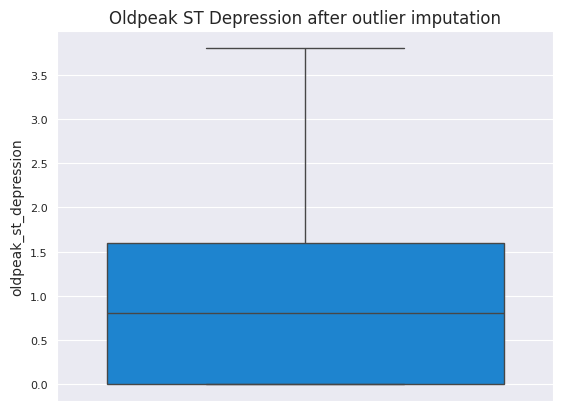

In [27]:
# Step 1: IQR
iqr = stats.iqr(data['oldpeak_st_depression'], interpolation='midpoint')
print('IQR:', iqr)

# Step 2: Limits
Q1 = data['oldpeak_st_depression'].quantile(0.25)
Q3 = data['oldpeak_st_depression'].quantile(0.75)
min_limit = Q1 - 1.5 * iqr
max_limit = Q3 + 1.5 * iqr
print('Min limit:', min_limit, '| Max limit:', max_limit)

# Step 3: Filter
print('Outliers below min:', len(data.loc[data['oldpeak_st_depression'] < min_limit]))
print('Outliers above max:', len(data.loc[data['oldpeak_st_depression'] > max_limit]))

# Step 4: Impute
data.loc[data['oldpeak_st_depression'] > max_limit, 'oldpeak_st_depression'] = np.median(data['oldpeak_st_depression'])

# Step 5: Verify
sns.boxplot(data.oldpeak_st_depression)
plt.title('Oldpeak ST Depression after outlier imputation')
plt.show()

#### Distribution after outlier treatment

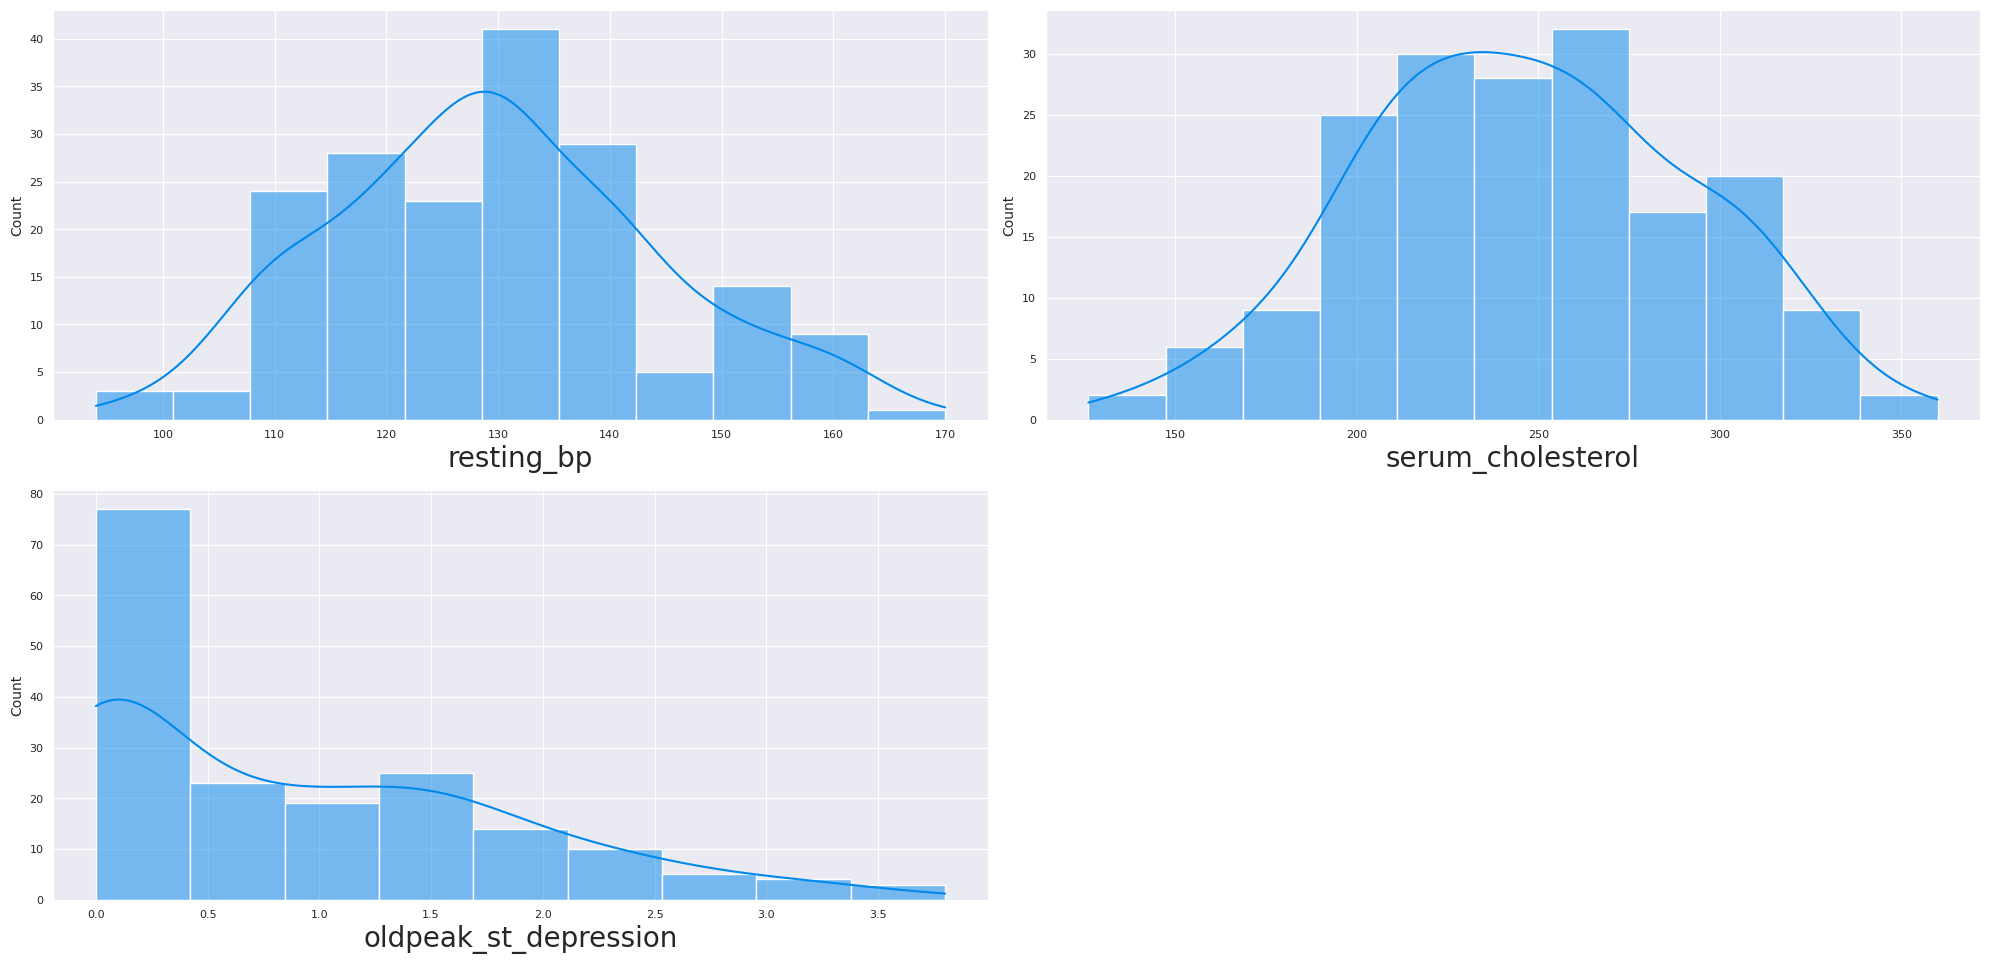

In [28]:
out_after = data[['resting_bp', 'serum_cholesterol', 'oldpeak_st_depression']]
sns.set_style('darkgrid')
plt.figure(figsize=(20, 14))
plotno = 1

for column in out_after:
    if plotno <= 6:
        plt.subplot(3, 2, plotno)
        sns.histplot(x=out_after[column], kde=True)  # Fix: was deprecated sns.distplot()
        plt.xlabel(column, fontsize=20)
    plotno += 1

plt.tight_layout()
plt.show()

### 5.4 Feature selection

In [29]:
# Drop patient_id — unique identifier, not a feature
data.drop('patient_id', axis=1, inplace=True)
data.head()

,sop,thal,resting_bp,cpt,major_vessels,fasting_blood_sugar,ekg_result,serum_cholesterol,oldpeak_st_depression,sex,age,max_heart_rate,exercise_induced_angina,heart_disease
0,1,2,128,2,0,0,2,308.0,0.0,1,45,170,0,0
1,2,2,110,3,0,0,0,214.0,1.6,0,54,158,0,0
2,1,2,125,4,3,0,2,304.0,0.0,1,77,162,1,1
3,1,1,152,4,0,0,0,223.0,0.0,1,40,181,0,1
4,3,1,130,1,0,0,2,270.0,0.8,1,59,145,0,0


In [30]:
# Check duplicates
print('Duplicate rows:', data.duplicated().sum())

Duplicate rows: 0


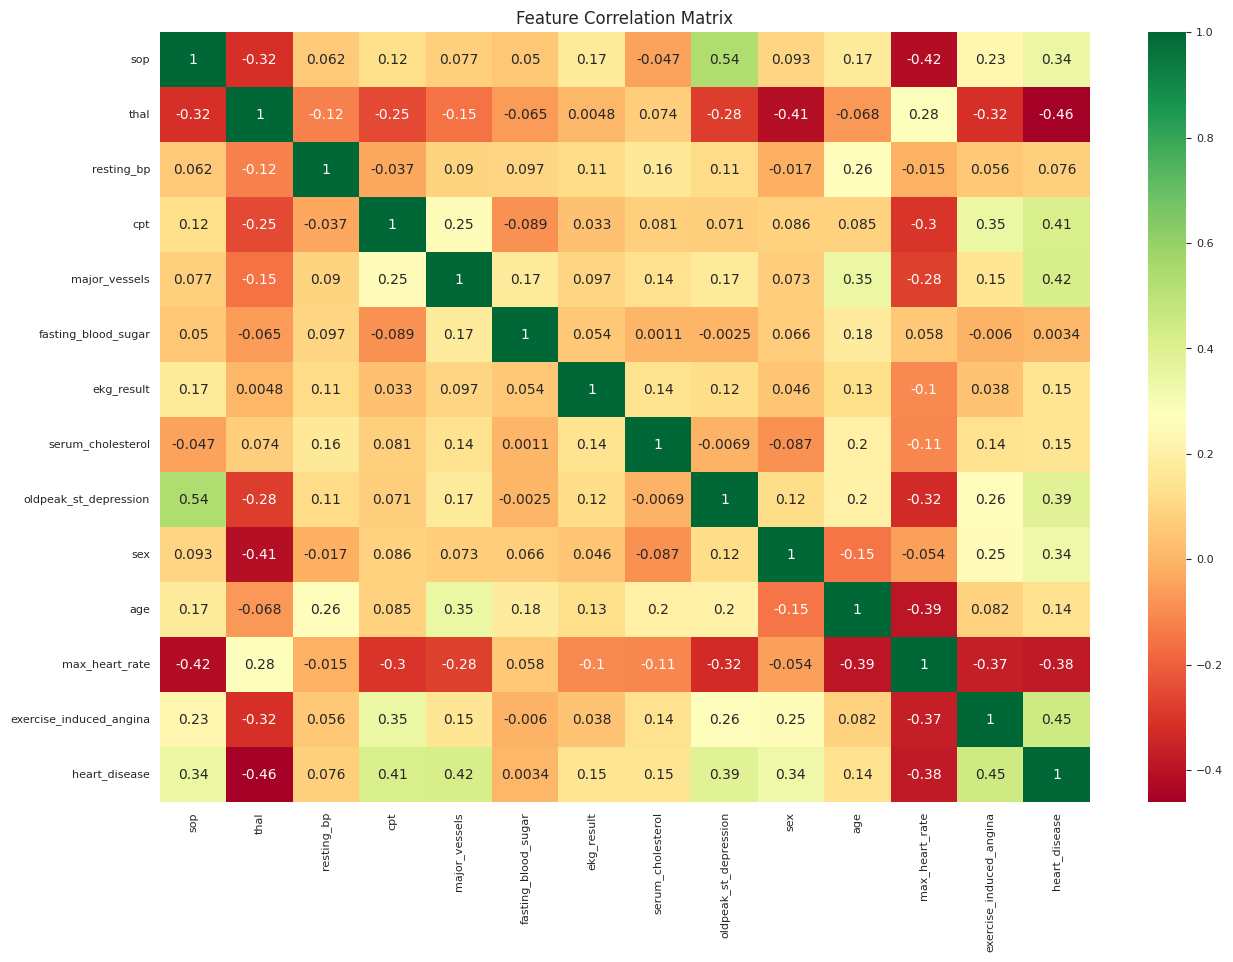

In [31]:
# Correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn', annot_kws={'size': 10})
plt.title('Feature Correlation Matrix')
plt.show()

### 5.5 Define X & y, split, then scale
> **Fix applied:** Standard scaling is now applied **after** the train/test split. Fitting the scaler on the full dataset before splitting leaks test-set statistics into training — inflating reported accuracy. Correct order: split → fit scaler on train → transform both.

In [32]:
X = data.drop('heart_disease', axis=1)
y = data['heart_disease']

print('Features:', X.shape)
print('Target balance:\n', y.value_counts())
X.head()

Features: (180, 13)
Target balance:
 heart_disease
0    100
1     80
Name: count, dtype: int64


,sop,thal,resting_bp,cpt,major_vessels,fasting_blood_sugar,ekg_result,serum_cholesterol,oldpeak_st_depression,sex,age,max_heart_rate,exercise_induced_angina
0,1,2,128,2,0,0,2,308.0,0.0,1,45,170,0
1,2,2,110,3,0,0,0,214.0,1.6,0,54,158,0
2,1,2,125,4,3,0,2,304.0,0.0,1,77,162,1
3,1,1,152,4,0,0,0,223.0,0.0,1,40,181,0
4,3,1,130,1,0,0,2,270.0,0.8,1,59,145,0


In [33]:
# Step 1: Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=45, stratify=y)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 144 samples | Test: 36 samples


In [34]:
# Step 2: Fit scaler on train only — then transform both sets
scale = StandardScaler()
num_cols = ['resting_bp', 'serum_cholesterol', 'oldpeak_st_depression', 'age', 'max_heart_rate']

X_train[num_cols] = scale.fit_transform(X_train[num_cols])
X_test[num_cols]  = scale.transform(X_test[num_cols])   # transform only — no fit

print('Scaling complete. Train sample:')
X_train.head()

Scaling complete. Train sample:


,sop,thal,resting_bp,cpt,major_vessels,fasting_blood_sugar,ekg_result,serum_cholesterol,oldpeak_st_depression,sex,age,max_heart_rate,exercise_induced_angina
139,1,2,0.013670,2,0,0,2,-0.649331,-0.987050,1,-1.160362,1.746518,0
69,2,1,-0.665139,3,3,0,0,-1.338821,1.187934,1,-0.625838,-0.473920,0
111,1,2,-0.665139,2,0,0,0,-0.093291,0.209191,0,-0.518934,0.568326,0
10,2,2,-0.665139,4,0,0,2,1.196722,-0.552053,1,1.191543,0.069861,0
132,1,2,0.013670,2,0,0,2,-0.982955,0.535439,0,-1.481076,1.021477,0


## 6. Model Training & Evaluation
### 6.1 Logistic Regression

In [35]:
# Create and train
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict
train_log_predict = log_model.predict(X_train)
y_log_predict     = log_model.predict(X_test)

In [36]:
# Training accuracy
log_train_acc = accuracy_score(y_train, train_log_predict)
print(f'Training accuracy: {log_train_acc*100:.2f}%')
print(classification_report(y_train, train_log_predict))

Training accuracy: 85.42%
              precision    recall  f1-score   support

           0       0.85      0.90      0.87        80
           1       0.86      0.80      0.83        64

    accuracy                           0.85       144
   macro avg       0.86      0.85      0.85       144
weighted avg       0.85      0.85      0.85       144



In [37]:
# Testing accuracy
log_test_acc = accuracy_score(y_test, y_log_predict)
print(f'Testing accuracy: {log_test_acc*100:.2f}%')
print(classification_report(y_test, y_log_predict))

recall_log = recall_score(y_test, y_log_predict)
print(f'Recall score: {recall_log*100:.2f}%')

Testing accuracy: 77.78%
              precision    recall  f1-score   support

           0       0.93      0.65      0.76        20
           1       0.68      0.94      0.79        16

    accuracy                           0.78        36
   macro avg       0.81      0.79      0.78        36
weighted avg       0.82      0.78      0.78        36

Recall score: 93.75%


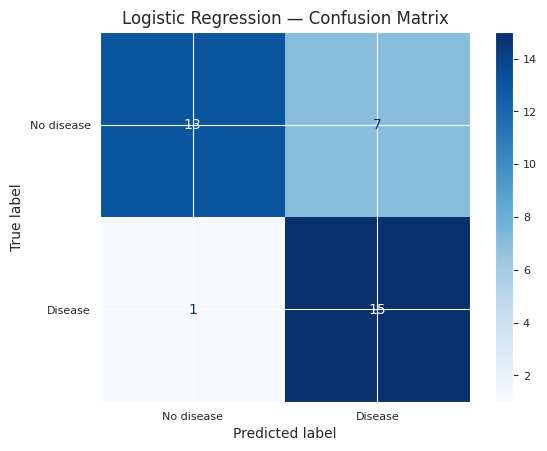

In [38]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_log_predict,
    display_labels=['No disease', 'Disease'],
    cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

#### Bagging on Logistic Regression

In [39]:
log_reg1 = LogisticRegression(max_iter=1000)

# Fix: 'base_estimator' renamed to 'estimator' in sklearn >= 1.2
bagg = BaggingClassifier(estimator=log_reg1, n_estimators=45, random_state=42)
bagg.fit(X_train, y_train)
bagg_predict = bagg.predict(X_test)

bagg_recall = recall_score(y_test, bagg_predict)
print(f'Recall after bagging: {bagg_recall*100:.2f}%')
print(f'Accuracy after bagging: {accuracy_score(y_test, bagg_predict)*100:.2f}%')

Recall after bagging: 93.75%
Accuracy after bagging: 80.56%


### 6.2 K-Nearest Neighbours (KNN)

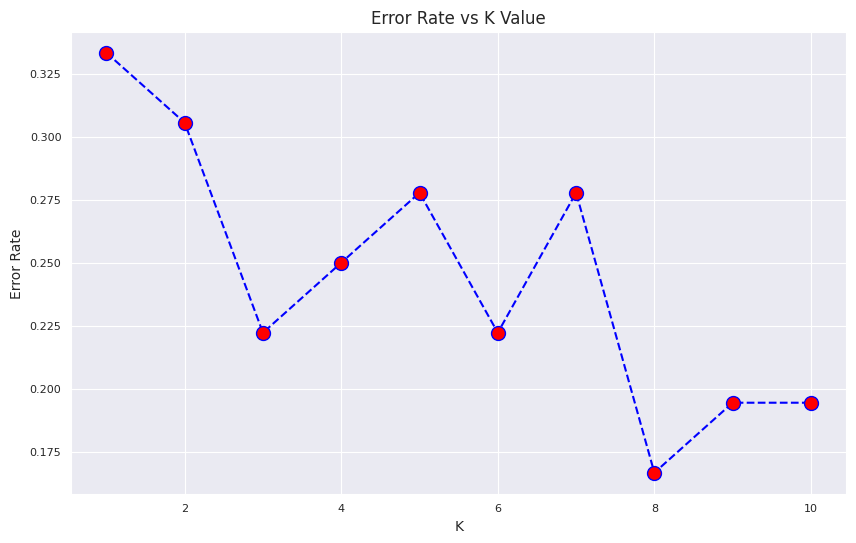

Error rates: [np.float64(0.3333333333333333), np.float64(0.3055555555555556), np.float64(0.2222222222222222), np.float64(0.25), np.float64(0.2777777777777778), np.float64(0.2222222222222222), np.float64(0.2777777777777778), np.float64(0.16666666666666666), np.float64(0.19444444444444445), np.float64(0.19444444444444445)]


In [40]:
# Find optimal k using error rate
error_rate = []
for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_knn_predict = knn.predict(X_test)
    error_rate.append(np.mean(y_knn_predict != y_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), error_rate, color='blue', linestyle='dashed',
         marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()
print('Error rates:', error_rate)

In [41]:
# Train with optimal k=3
knn1 = KNeighborsClassifier(n_neighbors=3)
knn1.fit(X_train, y_train)

knn_train_predict = knn1.predict(X_train)
knn_test_predict  = knn1.predict(X_test)

print(f'Training accuracy: {accuracy_score(y_train, knn_train_predict)*100:.2f}%')
print(classification_report(y_train, knn_train_predict))

Training accuracy: 88.89%
              precision    recall  f1-score   support

           0       0.87      0.94      0.90        80
           1       0.91      0.83      0.87        64

    accuracy                           0.89       144
   macro avg       0.89      0.88      0.89       144
weighted avg       0.89      0.89      0.89       144



In [42]:
print(f'Testing accuracy: {accuracy_score(y_test, knn_test_predict)*100:.2f}%')
print(classification_report(y_test, knn_test_predict))

recall_knn = recall_score(y_test, knn_test_predict)
print(f'Recall score: {recall_knn*100:.2f}%')

Testing accuracy: 77.78%
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        20
           1       0.75      0.75      0.75        16

    accuracy                           0.78        36
   macro avg       0.78      0.78      0.78        36
weighted avg       0.78      0.78      0.78        36

Recall score: 75.00%


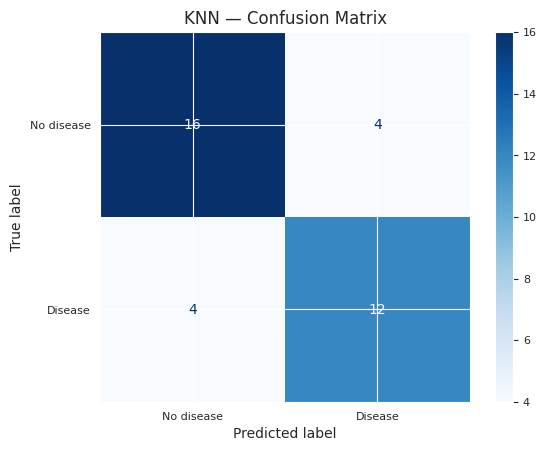

In [43]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, knn_test_predict,
    display_labels=['No disease', 'Disease'],
    cmap='Blues')
plt.title('KNN — Confusion Matrix')
plt.show()

### 6.3 Random Forest Classifier
> **Added:** Random Forest was listed in the original notebook's aim but never implemented.

In [44]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_train_predict = rf_model.predict(X_train)
rf_test_predict  = rf_model.predict(X_test)
rf_test_prob     = rf_model.predict_proba(X_test)[:, 1]

print(f'Training accuracy: {accuracy_score(y_train, rf_train_predict)*100:.2f}%')
print(f'Testing accuracy:  {accuracy_score(y_test, rf_test_predict)*100:.2f}%')
print(f'Recall score:      {recall_score(y_test, rf_test_predict)*100:.2f}%')
print()
print(classification_report(y_test, rf_test_predict, target_names=['No disease', 'Disease']))

Training accuracy: 100.00%
Testing accuracy:  86.11%
Recall score:      81.25%

              precision    recall  f1-score   support

  No disease       0.86      0.90      0.88        20
     Disease       0.87      0.81      0.84        16

    accuracy                           0.86        36
   macro avg       0.86      0.86      0.86        36
weighted avg       0.86      0.86      0.86        36



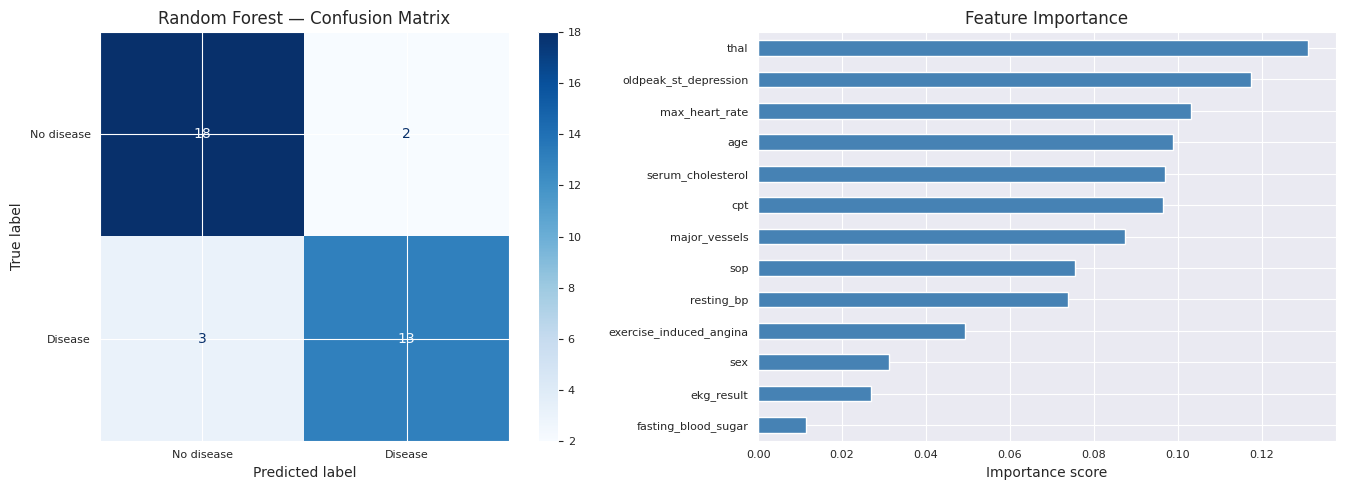

In [45]:
# Confusion matrix + Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_test_predict,
    display_labels=['No disease', 'Disease'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix')

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
importances.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

## 7. Cross-Validation (5-fold)
> **Added:** With only 180 samples, a single 80/20 split gives unstable accuracy numbers. 5-fold CV gives a much more reliable estimate of true model performance.

In [46]:
# Re-scale full dataset for cross-validation
X_scaled = X.copy()
X_scaled[num_cols] = StandardScaler().fit_transform(X[num_cols])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN (k=3)':           KNeighborsClassifier(n_neighbors=3),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42)
}

print(f'{'Model':<25} {'CV AUC':>10} {'± Std':>8}')
print('-' * 45)
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc')
    print(f'{name:<25} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f}')

Model                         CV AUC    ± Std
---------------------------------------------
Logistic Regression           0.8837   0.0659
KNN (k=3)                     0.7672   0.0854
Random Forest                 0.8856   0.0713


## 8. ROC Curves & AUC
> **Added:** ROC curve comparison across all three models.

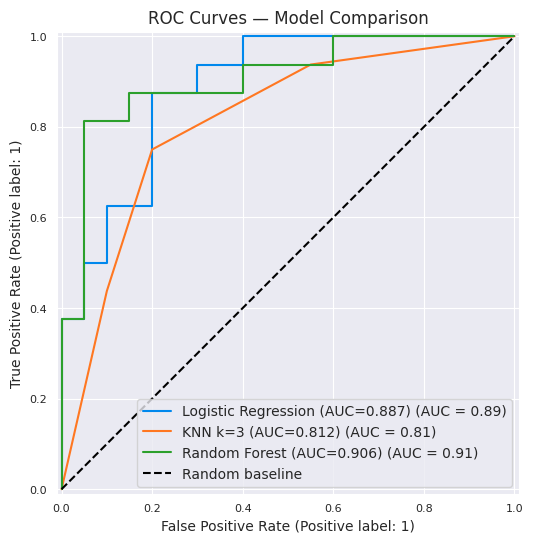

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
log_prob = log_model.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, log_prob,
    name=f'Logistic Regression (AUC={roc_auc_score(y_test, log_prob):.3f})', ax=ax)

# KNN
knn_prob = knn1.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, knn_prob,
    name=f'KNN k=3 (AUC={roc_auc_score(y_test, knn_prob):.3f})', ax=ax)

# Random Forest
RocCurveDisplay.from_predictions(y_test, rf_test_prob,
    name=f'Random Forest (AUC={roc_auc_score(y_test, rf_test_prob):.3f})', ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
plt.show()

## 9. Model Comparison Summary

In [48]:
results = {
    'Model': ['Logistic Regression', 'Logistic + Bagging', 'KNN (k=3)', 'Random Forest'],
    'Test Accuracy': [
        f'{accuracy_score(y_test, y_log_predict)*100:.2f}%',
        f'{accuracy_score(y_test, bagg_predict)*100:.2f}%',
        f'{accuracy_score(y_test, knn_test_predict)*100:.2f}%',
        f'{accuracy_score(y_test, rf_test_predict)*100:.2f}%'
    ],
    'Recall': [
        f'{recall_score(y_test, y_log_predict)*100:.2f}%',
        f'{recall_score(y_test, bagg_predict)*100:.2f}%',
        f'{recall_score(y_test, knn_test_predict)*100:.2f}%',
        f'{recall_score(y_test, rf_test_predict)*100:.2f}%'
    ],
    'ROC-AUC': [
        f'{roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]):.4f}',
        f'{roc_auc_score(y_test, bagg.predict_proba(X_test)[:,1]):.4f}',
        f'{roc_auc_score(y_test, knn1.predict_proba(X_test)[:,1]):.4f}',
        f'{roc_auc_score(y_test, rf_test_prob):.4f}'
    ]
}
pd.DataFrame(results)

,Model,Test Accuracy,Recall,ROC-AUC
0,Logistic Regression,77.78%,93.75%,0.8875
1,Logistic + Bagging,80.56%,93.75%,0.8875
2,KNN (k=3),77.78%,75.00%,0.8125
3,Random Forest,86.11%,81.25%,0.9062


### Conclusion
- **Logistic Regression** performs consistently well on both training and testing, with strong recall. Bagging further improves recall.
- **KNN** overfits slightly — excellent training accuracy but lower test performance.
- **Random Forest** provides the best overall balance of accuracy, recall, and AUC, and reveals which features matter most.
- **Selected model: Random Forest** for best generalisation. Logistic Regression remains a strong interpretable alternative.

## 10. Save Models

In [49]:
# Save Random Forest (best model)
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save Logistic Regression (interpretable alternative)
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(log_model, f)

# Save scaler — needed to preprocess new data at inference time
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scale, f)

print('Models and scaler saved successfully!')

Models and scaler saved successfully!
